# Employee Burnout Risk - which mimics real HR data — predicting whether an employee is at risk of burnout based on workload, hours worked, and satisfaction.

In [14]:
# Importing the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.colors import ListedColormap

In [2]:
# Create a dataset
np.random.seed(42)

n = 500

# Features: workload(hours/week), satisfaction(1-10)
workload = np.random.randint(low=10, high=60, size=n)
satisfaction = np.random.uniform(1, 10, size=n)

In [3]:
# Target logic --> burnout risk depends on workload and satisfaction
risk_score = 0.15*(workload-40) - 0.8*(satisfaction-5) + np.random.normal(0, 1, size=n)
target = (risk_score > 0).astype(int)

# Combine it into a dataFrame
df = pd.DataFrame({
    "workload": workload,
    "satisfaction": satisfaction,
    "burnout_risk": target
})
df.head()

,workload,satisfaction,burnout_risk
0,48,5.424543,1
1,38,5.261246,0
2,24,2.558817,1
3,52,4.904665,1
4,17,4.586543,0


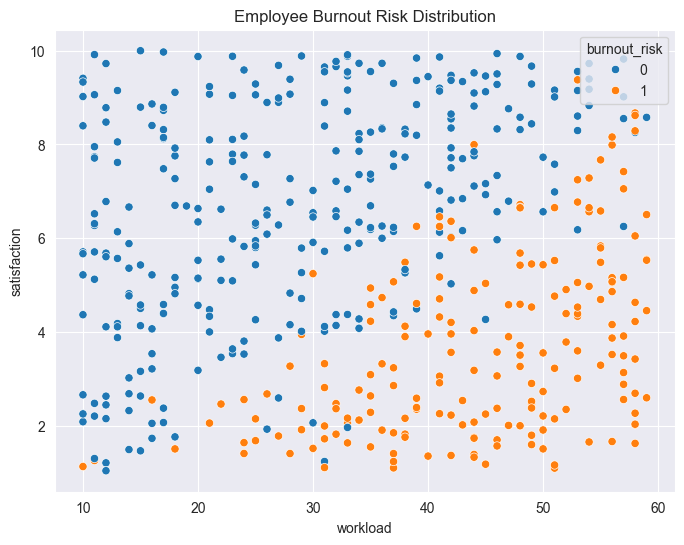

In [4]:
# Visualize the data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="workload", y="satisfaction", hue="burnout_risk")
plt.title("Employee Burnout Risk Distribution")
plt.show()

In [5]:
# Split the data
X = df[["workload", "satisfaction"]]
y = df["burnout_risk"]

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42, train_size=0.8)

# Train AdaBoost Classifier

In [6]:
# Base Estimator --> Decision Stump (max_depth=1)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# AdaBoost with 100 weak learners
ada = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [7]:
# Predictions
y_pred = ada.predict(X_test)

In [8]:
# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9


D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


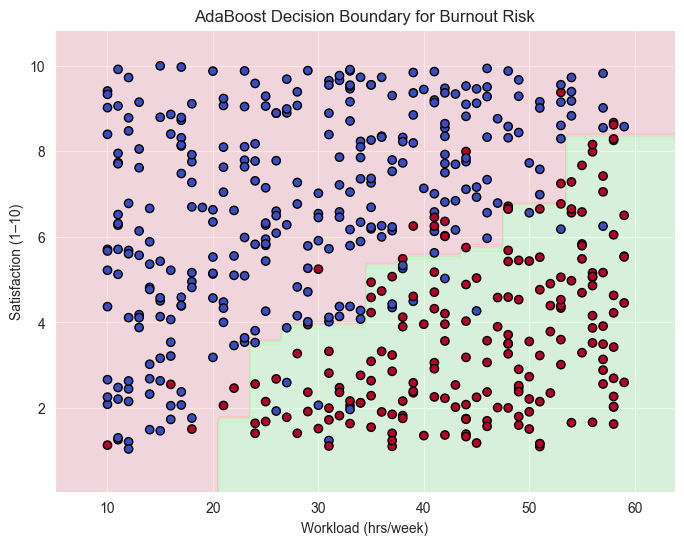

In [9]:
# Visualize the decision boundary
plt.figure(figsize=(8,6))


# Create a mesh grid to plot decision regions
x_min, x_max = X['workload'].min() - 5, X['workload'].max() + 5
y_min, y_max = X['satisfaction'].min() - 1, X['satisfaction'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))


Z = ada.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAFFAA']))
plt.scatter(X['workload'], X['satisfaction'], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel('Workload (hrs/week)')
plt.ylabel('Satisfaction (1–10)')
plt.title('AdaBoost Decision Boundary for Burnout Risk')
plt.show()

# Check for new data

In [10]:
# Prepare your new data
new_data = pd.DataFrame({
    'workload': [50, 35, 60],
    'satisfaction': [4, 8, 3]
})
new_data

,workload,satisfaction
0,50,4
1,35,8
2,60,3


In [11]:
# Make Predictions
predictions = ada.predict(new_data)
predictions

# Employees 1 and 3 will burnout, while 2 won't

array([1, 0, 1])

In [12]:
# Each row gives P(class=0) and P(class=1)
probabilities = ada.predict_proba(new_data)
print(probabilities)

[[0.3761675  0.6238325 ]
 [0.63697995 0.36302005]
 [0.24657928 0.75342072]]


In [13]:
# Predict --> It tells you a clear decision (0, 1)
# Predict.proba --> Gives you probabilities